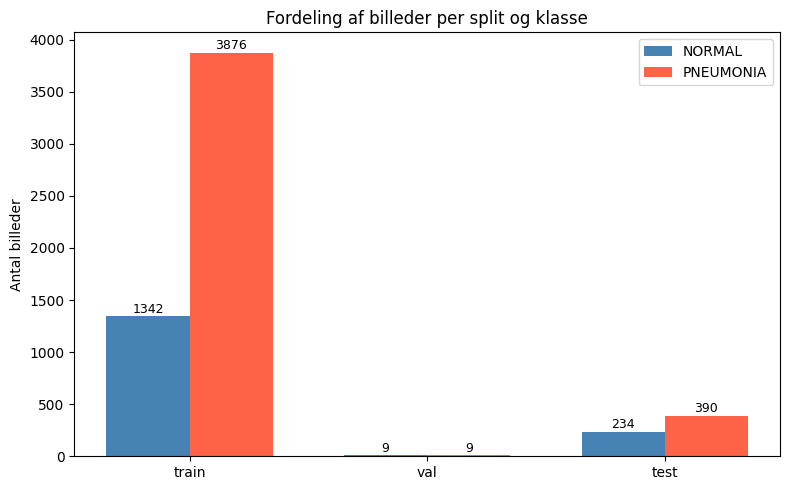

In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

BASE = "../billeder/chest_xray"
splits = ["train", "val", "test"]
classes = ["NORMAL", "PNEUMONIA"]
IMAGE_EXTS = {".jpg", ".jpeg", ".png"}

# Count images per split and class (skip non-image files like .DS_Store)
counts = {}
for split in splits:
    counts[split] = {}
    for cls in classes:
        path = os.path.join(BASE, split, cls)
        counts[split][cls] = len([f for f in os.listdir(path) if os.path.splitext(f)[1].lower() in IMAGE_EXTS])

# Bar chart
x = np.arange(len(splits))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, [counts[s]["NORMAL"] for s in splits], width, label="NORMAL", color="steelblue")
bars2 = ax.bar(x + width/2, [counts[s]["PNEUMONIA"] for s in splits], width, label="PNEUMONIA", color="tomato")

ax.set_xticks(x)
ax.set_xticklabels(splits)
ax.set_ylabel("Number of images")
ax.set_title("Image distribution per split and class")
ax.legend()

# Add count labels on top of each bar
for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

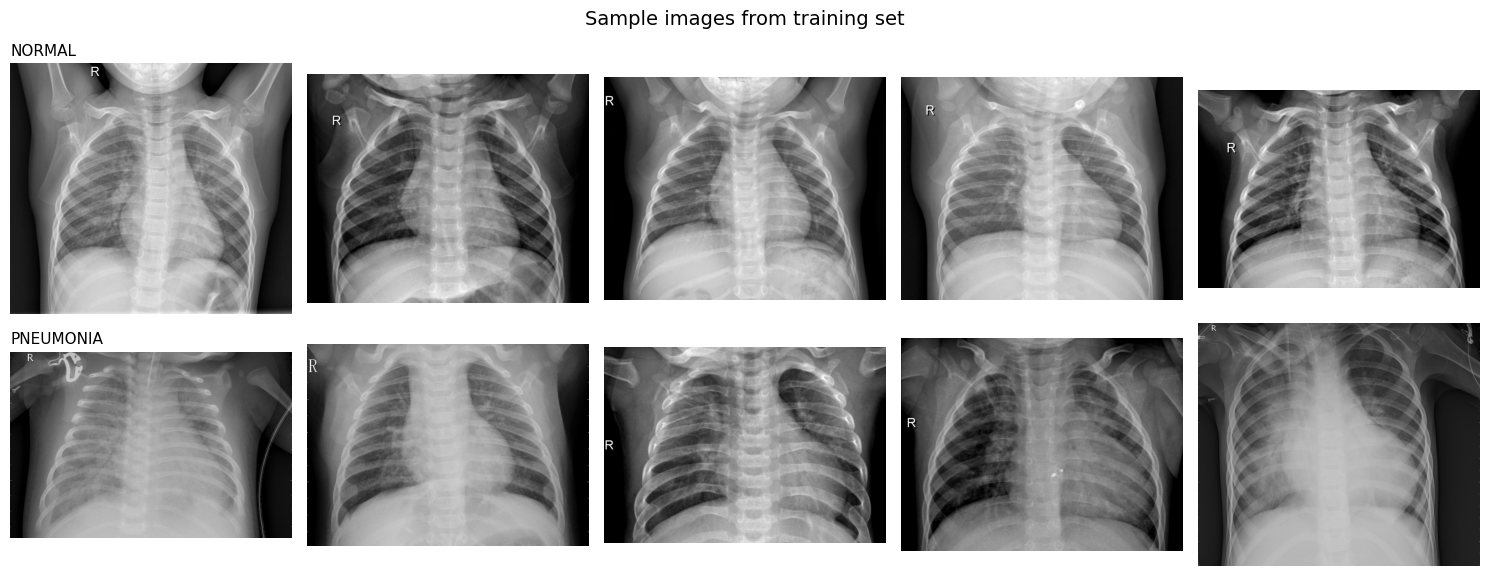

In [6]:
# Show sample images from the training set
IMAGE_EXTS = {".jpg", ".jpeg", ".png"}
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Sample images from training set", fontsize=14)

for row, cls in enumerate(classes):
    path = os.path.join(BASE, "train", cls)
    files = [f for f in os.listdir(path) if os.path.splitext(f)[1].lower() in IMAGE_EXTS][:5]
    for col, fname in enumerate(files):
        img = mpimg.imread(os.path.join(path, fname))
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_title(cls, fontsize=11, loc="left")

plt.tight_layout()
plt.show()